# 입력과CNN설계

사진 입력을 직접 변환하고, CNN을 설계·학습한 뒤 다른 구조와 비교합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [1]:
from pathlib import Path
import os, sys, json, time
# root 자동 탐색 코드
# ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'signlab.py').exists()), None)
# if ROOT is None: raise RuntimeError('오전_최종본 폴더에서 실행하세요.')

# 기존 자동 탐색 코드를 지우고, 확인된 절대 경로를 직접 주입합니다.  - 00 오전 실습 준비에서 위치 찾아서 수정
ROOT = Path(r"C:\Users\User\.ngv_day4_2026\am\9de5e80f5a44")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
import signlab as lab

data=lab.load_data()
NAMES=lab.NAMES_KO


## 입력 확인 · 제공 예제
RGB 채널 분리와 색 순서의 차이를 먼저 확인합니다.


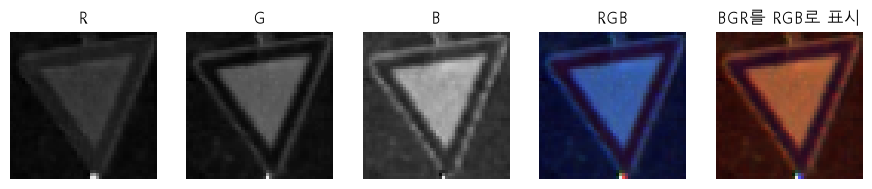

입력 배열: (48, 48, 3) uint8
빨간 채널 일부: [[54 56 55 49 49]
 [54 56 57 53 53]
 [55 55 58 59 53]
 [56 53 56 58 54]
 [57 55 56 56 54]]


In [2]:
pixels=data['val'].images[379]
fig,axes=plt.subplots(1,5,figsize=(11,3))
for ax,value,title in zip(axes,[pixels[:,:,0],pixels[:,:,1],pixels[:,:,2],pixels,pixels[:,:,::-1]],['R','G','B','RGB','BGR를 RGB로 표시']):
    ax.imshow(value,cmap='gray',vmin=0,vmax=255);ax.set_title(title);ax.axis('off')
plt.show();print('입력 배열:',pixels.shape,pixels.dtype)
print('빨간 채널 일부:',pixels[20:25,20:25,0])


## ✏️ A01 · 모델 입력 배치 구현

입력: 같은 크기의 uint8 사진 목록, 색 순서 `RGB` 또는 `BGR`.
반환: RGB 순서의 float32 `[N,3,H,W]` 텐서. 값은 `(픽셀/255−0.5)/0.5`.
원본 배열을 변경하지 마세요. 축 순서·색 순서·값 변환을 모두 처리합니다.

### 사용할 수 있는 API
`torch.from_numpy`, `.float()`, `.permute`, `torch.stack`, `np.ascontiguousarray`.
예: `torch.zeros(2,5,3).permute(2,0,1)`의 크기는 `[3,2,5]`.
예: `values[:, :, ::-1]`은 마지막 축 순서를 뒤집습니다.


In [3]:
# ===== 실습 A01 시작 =====

def make_batch(images,color_order='RGB'):
    # 사진별 변환 후 배치로 합치세요.
    tensors=[]
    for pixels in images:
        rgb=pixels if color_order=='RGB' else pixels[:,:,::-1]
        tensor=torch.from_numpy(np.array(rgb,copy=True)).float().permute(2,0,1)/255
        tensors.append((tensor-.5)/.5)
    return torch.stack(tensors)

    raise NotImplementedError('A01: 입력 배치 구현')

# ===== 실습 A01 끝 =====

**A01 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [4]:
rng=np.random.default_rng(42)
images=[rng.integers(0,256,(7,11,3),dtype=np.uint8) for _ in range(3)]
original=[a.copy() for a in images]
expected=torch.stack([lab.TO_TENSOR(Image.fromarray(a)) for a in images])
for order,values in [('RGB',images),('BGR',[a[:,:,::-1] for a in images])]:
    actual=make_batch(values,order)
    assert actual.shape==(3,3,7,11) and actual.dtype==torch.float32,'A01: 배치/채널/높이/너비를 확인하세요.'
    assert torch.allclose(actual,expected),'A01: 색 순서와 정규화를 확인하세요.'
assert all(np.array_equal(a,b) for a,b in zip(images,original))
print('A01 통과: RGB/BGR·비정사각형·배치·원본 보존')


A01 통과: RGB/BGR·비정사각형·배치·원본 보존


## CNN 설계 조건
입력 `[N,3,48,48]`, 출력 `[N,8]` logits입니다. 특징 추출부 `self.features`와 분류부 `self.classifier`를 직접 구성합니다.
합성곱·활성화·공간 축소를 포함하고, Flatten 뒤의 입력 개수를 맞추세요. 끝에 Softmax를 넣지 않습니다.
**설계값 셀**부터 재실행하면 다른 구조를 같은 조건으로 비교할 수 있습니다.


In [5]:
# 설계값 셀: 한 번에 하나만 바꾸세요. 층 추가·삭제는 아래 클래스에서 합니다.
CHANNELS=(8,16,32)
KERNEL=3
POOL_OUT=4
HIDDEN=64
EPOCHS=10


## ✏️ A02 · CNN 전체 연결 설계

특징 추출부와 분류부를 각각 nn.Sequential로 구성하고 forward를 완성하세요. 층 수·채널·풀링 위치는 선택할 수 있습니다.
예시 답안과 같은 구조일 필요는 없습니다. 설계값은 사용하는 구조에 맞게 연결하세요.

### 사용할 수 있는 API
`nn.Sequential`, `nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)`, `nn.BatchNorm2d`, `nn.ReLU`, `nn.MaxPool2d(2)`, `nn.AdaptiveAvgPool2d((4,4))`, `nn.Flatten`, `nn.Linear`.
독립 블록 예: `nn.Sequential(nn.Conv2d(3,6,kernel_size=5,padding=2), nn.ReLU())`.
`Linear` 입력은 앞 특징맵의 채널×높이×너비입니다.


In [6]:
# ===== 실습 A02 시작 =====

class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 전역 혹은 이전 셀에 정의된 변수들을 가져옵니다.
        c1, c2, c3 = CHANNELS
        
        # 1. 특징 추출부 (Features) 설계, 풀링하는 과정에서 사이즈가 계속 바뀌기 때문에 주의해야한다.
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=KERNEL, padding=KERNEL//2), nn.BatchNorm2d(c1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(c1, c2, kernel_size=KERNEL, padding=KERNEL//2), nn.BatchNorm2d(c2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(c2, c3, kernel_size=KERNEL, padding=KERNEL//2), nn.BatchNorm2d(c3), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4))
        ) 
        
        # 2. 분류기 (Classifier) 설계
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(c3 * POOL_OUT * POOL_OUT, HIDDEN), 
            nn.ReLU(), 
            nn.Linear(HIDDEN, len(NAMES)) # <- 최종 출력은 수어 클래스 개수(len(NAMES))로 지정
        )
        
    def forward(self, x):
        # 3. 특징 추출부와 분류기를 순서대로 연결하여 반환합니다.
        x = self.features(x)
        x = self.classifier(x)
        return x

# ===== 실습 A02 끝 =====


**A02 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [7]:
model=StudentCNN().eval()
assert isinstance(model.features,nn.Sequential) and isinstance(model.classifier,nn.Sequential),'A02: 두 부분은 nn.Sequential로 구성하세요.'
assert any(isinstance(m,nn.Conv2d) for m in model.features.modules()),'A02: 특징 추출부에 합성곱 층이 필요합니다.'
activations=(nn.ReLU,nn.LeakyReLU,nn.PReLU,nn.ELU,nn.GELU,nn.SiLU,nn.Tanh,nn.Sigmoid,nn.Hardswish)
assert any(isinstance(m,activations) for m in model.features.modules()),'A02: 특징 추출부에 활성화 층이 필요합니다.'
assert not any(isinstance(m,(nn.Softmax,nn.LogSoftmax)) for m in model.modules()),'A02: 출력은 logits여야 합니다.'
with torch.inference_mode():
    z=torch.zeros(1,3,48,48);reduced=False
    for layer in model.features:
        z=layer(z)
        if z.ndim==4 and z.shape[-2]<48 and z.shape[-1]<48:reduced=True
    assert reduced,'A02: 풀링 또는 stride 등으로 높이·너비를 줄이세요.'
    for n in [1,3]:
        x=make_batch(list(data['val'].images[:n]));y=model(x)
        assert y.shape==(n,8) and torch.isfinite(y).all(),'A02: 출력 크기·연결을 확인하세요.'
        assert torch.allclose(y,model.classifier(model.features(x)))
print(model)
print('A02 통과: 합성곱·활성화·공간 축소·logits·배치 연결')
print('파라미터 수:',sum(p.numel() for p in model.parameters()))


StudentCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=8, bias=True)

## ✏️ A03 · 학습 한 단계 구성

입력으로 받은 모델·사진·정답·optimizer·손실 함수를 사용해 한 번 학습하세요.
가중치를 갱신하고 해당 단계의 손실을 Python float로 반환합니다.

### 사용할 수 있는 API
`optimizer.zero_grad`: 이전 기울기 초기화. `model(x)`: 예측. `criterion`: 손실 계산.
`loss.backward`: 기울기 계산. `optimizer.step`: 가중치 갱신.
`float(tensor.detach())`: 기울기 연결 없이 숫자 추출. 각 기능을 필요한 순서로 연결하세요.


In [ ]:
# ===== 실습 A03 시작 =====

def train_step(model,x,y,optimizer,criterion):
    optimizer.zero_grad()
    logits =model(x)
    loss=criterion(logits,y) # loss 기반으로 backword하기 위한 과정...
    loss.backword()
    optimizer.step()
    return float(loss.detach())
    #raise NotImplementedError('A03: 학습 단계 구성')

# ===== 실습 A03 끝 =====
# optimizer... 
# loss 를 줄이고자 하고 싶은데, 2차함수에서 가장 작은 값으로 가는 방향에 대해서 고민해보자 
# 항상 미분했을때, 그 선의 아래를 향하는 방향으로 가면 최저점에 향하게 될 것. 
# 미분의 감소하는 방향으로 함수의 점에서 내려가고, 미분, 내려가면 ...
# 이걸 하는게 옵


**A03 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [9]:
# 두 번 연속 갱신해 기울기 초기화 누락까지 확인합니다.
import copy
torch.manual_seed(42)
reference=nn.Sequential(nn.Linear(4,6),nn.ReLU(),nn.Linear(6,3))
probe=copy.deepcopy(reference)
reference_optimizer=torch.optim.SGD(reference.parameters(),lr=.03)
probe_optimizer=torch.optim.SGD(probe.parameters(),lr=.03)
criterion=nn.CrossEntropyLoss()
batches=[(torch.tensor([[1.,0.,-1.,2.],[0.,2.,1.,-1.]]),torch.tensor([0,2])),
         (torch.tensor([[-1.,1.,2.,0.],[2.,-1.,0.,1.]]),torch.tensor([1,0]))]
for x,y in batches:
    reference_optimizer.zero_grad()
    expected_loss=criterion(reference(x),y)
    expected_loss.backward();reference_optimizer.step()
    actual_loss=train_step(probe,x,y,probe_optimizer,criterion)
    assert np.isclose(actual_loss,float(expected_loss.detach()),rtol=1e-5), 'A03: 예측·손실 계산을 확인하세요.'
    assert all(torch.allclose(a,b,rtol=1e-5,atol=1e-7) for a,b in zip(probe.parameters(),reference.parameters())), 'A03: 기울기 초기화 → 역전파 → 가중치 갱신 순서를 확인하세요.'
print('A03: 연속 두 단계의 손실·가중치 검증 완료')


AttributeError: 'Tensor' object has no attribute 'backword'

## 실제 학습과 구조 비교 · 제공 코드
작성한 입력 함수·CNN·학습 함수가 모두 사용됩니다.
처음에는 기본 모델도 학습합니다. 같은 epoch의 기본 모델은 이후 재사용합니다.
첫 실행 후 설계값 또는 층 연결 하나를 바꾸고 **설계값 셀부터 끝까지 재실행**하세요.


In [ ]:
@torch.inference_mode()
def evaluate(model,dataset,batch_size=64):
    model.eval()
    truth,pred,scores = [],[],[]
    total_loss = 0.0
    for x,y in DataLoader(dataset,batch_size=batch_size,shuffle=False,num_workers=0):
        logits = model(x)
        total_loss += nn.functional.cross_entropy(logits,y,reduction='sum').item()
        probabilities = logits.softmax(1)
        confidence,labels = probabilities.max(1)
        truth.extend(y.tolist());pred.extend(labels.tolist());scores.extend(confidence.tolist())
    truth,pred = np.asarray(truth),np.asarray(pred)
    matrix = np.zeros((8,8),dtype=int)
    np.add.at(matrix,(truth,pred),1)
    return {'accuracy':float((truth==pred).mean()),'loss':total_loss/len(dataset),
            'truth':truth,'prediction':pred,'scores':np.asarray(scores),'confusion':matrix}
class InputDataset(Dataset):
    def __init__(self,source):self.source=source
    def __len__(self):return len(self.source)
    def __getitem__(self,i):return make_batch([self.source.images[i]])[0],int(self.source.labels[i])

def fit_model(factory):
    lab.seed_all(42);model=factory()
    loader=DataLoader(InputDataset(data['train']),batch_size=64,shuffle=True,generator=torch.Generator().manual_seed(42),num_workers=0)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=.0001)
    history=[];start=time.perf_counter()
    for epoch in range(EPOCHS):
        model.train();total=count=0
        for x,y in loader:
            total+=train_step(model,x,y,optimizer,nn.CrossEntropyLoss())*len(y);count+=len(y)
        history.append(total/count);print(epoch+1,'/',EPOCHS,'손실',round(history[-1],4),flush=True)
    return model,history,time.perf_counter()-start,evaluate(model,InputDataset(data['val']))

In [ ]:
if 'baseline_cache' not in globals():baseline_cache={}
if EPOCHS not in baseline_cache:baseline_cache[EPOCHS]=fit_model(lab.SmallCNN)
trained_model,losses,seconds,result=fit_model(StudentCNN)
base,base_losses,base_seconds,base_result=baseline_cache[EPOCHS]
fig,axes=plt.subplots(1,2,figsize=(9,3))
for name,history in [('기본',base_losses),('학생',losses)]:axes[0].plot(range(1,EPOCHS+1),history,label=name)
axes[0].set_title('학습 손실');axes[0].legend()
bars=axes[1].bar(['기본','학생'],[base_result['accuracy'],result['accuracy']]);axes[1].set_ylim(0,1.1)
axes[1].bar_label(bars,labels=[f"{r['accuracy']:.2%}" for r in [base_result,result]]);axes[1].set_title('검증 정답률');plt.show()
trace=[];trained_model.eval()
with torch.inference_mode():
    x=torch.zeros(1,3,48,48)
    for layer in trained_model.features:
        x=layer(x);trace.append((type(layer).__name__,tuple(x.shape[1:])))
if 'architecture_trials' not in globals():architecture_trials=[]
trial=dict(architecture=str(trained_model),epochs=EPOCHS,parameters=sum(p.numel() for p in trained_model.parameters()),accuracy=result['accuracy'],train_seconds=seconds,shapes=trace)
architecture_trials[:]=[r for r in architecture_trials if (r['architecture'],r['epochs'])!=(trial['architecture'],EPOCHS)]
architecture_trials.append(trial)
comparable=[r for r in architecture_trials if r['epochs']==EPOCHS]
for i,r in enumerate(comparable,1):print('구조',i,'파라미터',r['parameters'],'정답률',r['accuracy'],'학습 시간(초)',round(r['train_seconds'],1),'층별 크기',r['shapes'])
if len(comparable)<2:print('구조 하나를 바꾸고 설계값 셀부터 끝까지 다시 실행하세요.')
else:
    before,after=comparable[-2:]
    print('구조 비교 완료 / 파라미터 변화:',after['parameters']-before['parameters'],'정답률 변화(%p):',100*(after['accuracy']-before['accuracy']))
output_dir=ROOT/'outputs/student_model';output_dir.mkdir(parents=True,exist_ok=True)
with (output_dir/'latest.pt').open('wb') as file:torch.jit.save(torch.jit.trace(trained_model.eval(),torch.zeros(1,3,48,48)),file)
(output_dir/'latest.json').write_text(json.dumps(trial,ensure_ascii=False,indent=2),encoding='utf-8')
print('카메라에서 사용할 모델을 저장했습니다.')